# Candidate SPX quote audit

Milestone 2 — observed-data diagnostics, not a market-implied density.

We have moved from perfect theoretical prices to a retrieved option-chain payload from Cboe [2]. The question is whether its fields support defensible estimation. Read `research/market_data_methodology.md` for Equations (5)–(8), references and the full decision record. Run from the project directory.

In [1]:
from run_quote_audit import main
main()

{
  "raw_rows": 27782,
  "local_price_screen_pass": 25866,
  "relative_spread_threshold": 0.25,
  "exclusion_counts": {
    "zero_bid": 697,
    "wide_spread": 1916
  },
  "warning_counts": {
    "unconfirmed_bid_size": 27782,
    "unconfirmed_ask_size": 27782
  },
  "root_expiry_groups": 61,
  "quote_timestamp_raw": "17:43:22",
  "density_estimation_ready": false,
  "blocking_checks": [
    "Full quote observation datetime and timezone must be verified",
    "Settlement datetime and contract convention must be verified",
    "Discount factor and forward must be established",
    "Quote sizes, price shape and strike coverage require review"
  ],
  "spread_threshold_sensitivity": {
    "0.1": 24721,
    "0.25": 25866,
    "0.5": 26475
  }
}


## Interpretation

25,866 of 27,782 records pass the provisional price screen, but none are approved for calibration yet. The quote timestamp lacks a date and timezone, and all bid/ask sizes are zero. Passing a spread filter cannot repair missing provenance. Exclusion reasons can overlap.

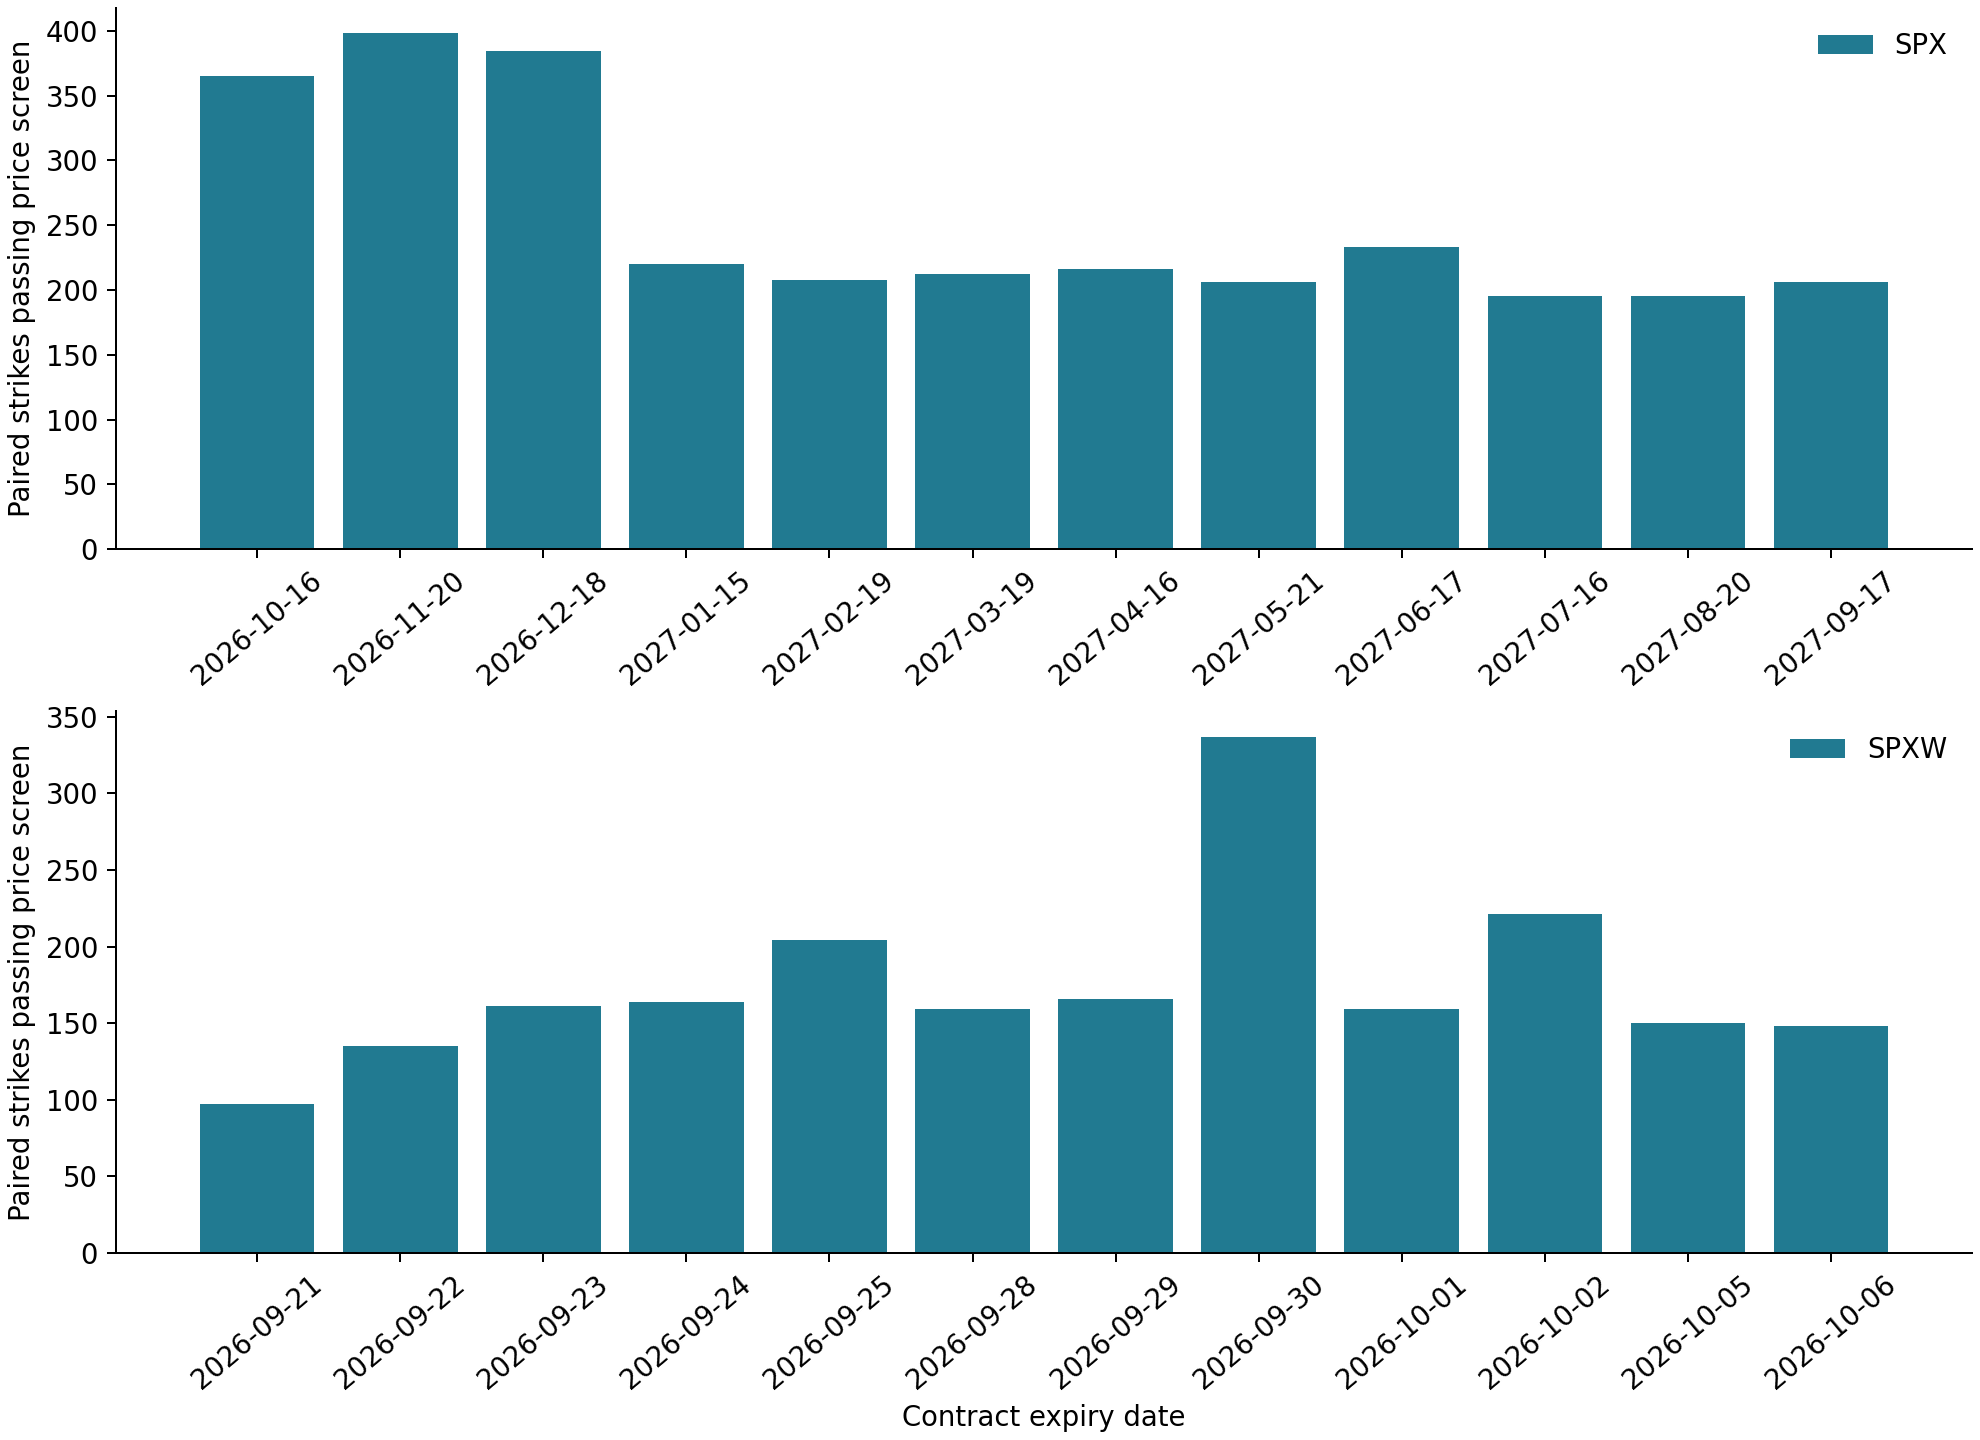

In [2]:
from IPython.display import Image, display
display(Image(filename="figures/figure_05_quote_coverage.png"))

Figure 5. Paired call–put strikes passing the 25% price screen for the first twelve expiry dates in each root. Expiry labels are not verified settlement horizons.

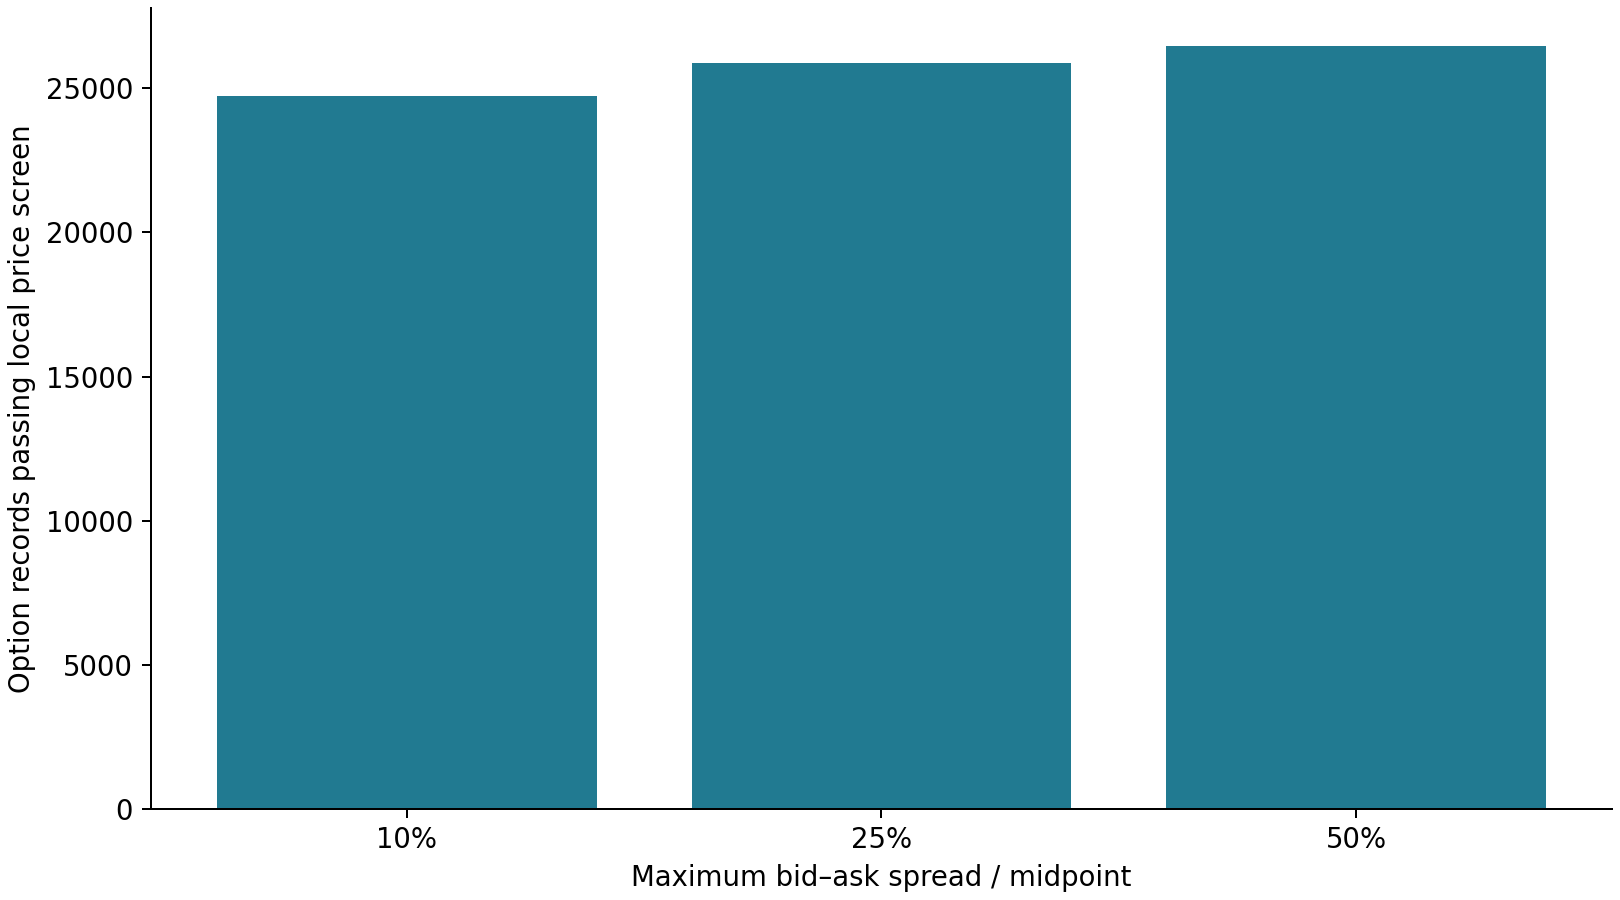

In [3]:
from IPython.display import Image, display
display(Image(filename="figures/figure_06_spread_sensitivity.png"))

Figure 6. Passing records under 10%, 25% and 50% relative-spread thresholds. Looser thresholds retain more records but do not resolve timestamp or quote-size limitations.

## Next step

Verify or replace the candidate snapshot before fitting. Confirm full quote observation time and timezone, settlement convention, discount factor, forward consistency and adequate strike coverage. Only then fit a monotone, convex call-price curve and extract its density.

As Aït-Sahalia and Lo (1998) explain [10, §III.A], contemporaneous matched calls and puts support a parity-based forward estimate. Aït-Sahalia and Duarte (2003) establish the relevance of monotonicity and convexity constraints for the fitted option-price curve [9, §2]. These motivate the next stage; neither paper validates our candidate snapshot.


## References

[2] Cboe, “SPX delayed quotes.” Retrieved 19 September 2026. [Source page](https://www.cboe.com/delayed_quotes/spx/quote_table). Primary data source; not a research paper.

[9] Y. Aït-Sahalia and J. Duarte (2003), “Nonparametric option pricing under shape restrictions,” *Journal of Econometrics*, vol. 116, nos. 1–2, pp. 9–47. Section 2. [doi:10.1016/S0304-4076(03)00102-7](https://doi.org/10.1016/S0304-4076(03)00102-7); [author-hosted paper](https://www.princeton.edu/~yacine/cnvx.pdf).

[10] Y. Aït-Sahalia and A. W. Lo (1998), “Nonparametric Estimation of State-Price Densities Implicit in Financial Asset Prices,” *The Journal of Finance*, vol. 53, no. 2, pp. 499–547. Sections I and III.A, especially Equations (16)–(17). [Author-hosted paper](https://www.princeton.edu/~yacine/aslo.pdf).